In [2]:
from insilico_stimuli.stimuli import CenterSurround
import numpy as np
import matplotlib.pyplot as plt

seed = 42
rng = np.random.default_rng(seed)

# Fixed parameters
canvas_size = [36, 36]
locations = [[18, 18]]  
sizes_total = [36]  
sizes_center = [0.5]  
sizes_surround = [0.5]  
contrasts_center = [1.0]  
contrasts_surround = [1.0]  
grey_levels = [0.0]  
phase = np.pi/2  # Fixed phase for all gratings
# spatial_frequency = 0.2
# Generate 1000 different parameter combinations
n_gratings = 1000
gratings = []
grating_params = []

print(f"Generating {n_gratings} gratings...")

for i in range(n_gratings):
    # Randomly vary orientation, spatial frequency, and phase
    orientation = rng.uniform(-np.pi/2, np.pi/2)  # Random orientation
    spatial_freq = rng.uniform(1/20, 1/5)          # Random spatial frequency  
    
    # Create CenterSurround with single parameter set (center = surround)
    center_surround = CenterSurround(
        canvas_size=canvas_size,
        locations=locations,
        sizes_total=sizes_total,
        sizes_center=sizes_center,
        sizes_surround=sizes_surround,
        contrasts_center=contrasts_center,
        contrasts_surround=contrasts_surround,
        orientations_center=[orientation],      # Same orientation for center and surround
        orientations_surround=[orientation],    # Same orientation for center and surround
        spatial_frequencies_center=[spatial_freq],  # Same spatial freq for center and surround
        phases_center=[phase],                  # Same phase for center and surround
        phases_surround=[phase],            # Same phase for center and surround
        grey_levels=grey_levels,
    )
    
    # Generate the single image (index 0 since we only have one combination)
    grating_image = center_surround.images()[0]
    gratings.append(grating_image)
    
    # Store parameters for reference
    grating_params.append({
        'grating_id': i,
        'orientation': orientation,
        'spatial_frequency': spatial_freq,
        'phase': phase
    })
    
    if (i + 1) % 100 == 0:
        print(f"Generated {i + 1}/{n_gratings} gratings...")

gratings = np.array(gratings)
print(f"Generated {len(gratings)} gratings with shape {gratings.shape}")
print(f"\nParameter ranges:")
print(f"Orientation: {min(p['orientation'] for p in grating_params):.3f} to {max(p['orientation'] for p in grating_params):.3f}")
print(f"Spatial freq: {min(p['spatial_frequency'] for p in grating_params):.3f} to {max(p['spatial_frequency'] for p in grating_params):.3f}")
print(f"Phase: {min(p['phase'] for p in grating_params):.3f} to {max(p['phase'] for p in grating_params):.3f}")

Generating 1000 gratings...
Generated 100/1000 gratings...
Generated 200/1000 gratings...
Generated 300/1000 gratings...
Generated 400/1000 gratings...
Generated 500/1000 gratings...
Generated 600/1000 gratings...
Generated 700/1000 gratings...
Generated 800/1000 gratings...
Generated 900/1000 gratings...
Generated 1000/1000 gratings...
Generated 1000 gratings with shape (1000, 36, 36)

Parameter ranges:
Orientation: -1.569 to 1.569
Spatial freq: 0.050 to 0.200
Phase: 1.571 to 1.571
Generated 600/1000 gratings...
Generated 700/1000 gratings...
Generated 800/1000 gratings...
Generated 900/1000 gratings...
Generated 1000/1000 gratings...
Generated 1000 gratings with shape (1000, 36, 36)

Parameter ranges:
Orientation: -1.569 to 1.569
Spatial freq: 0.050 to 0.200
Phase: 1.571 to 1.571


Creating 3 high-resolution 7x7 grids...


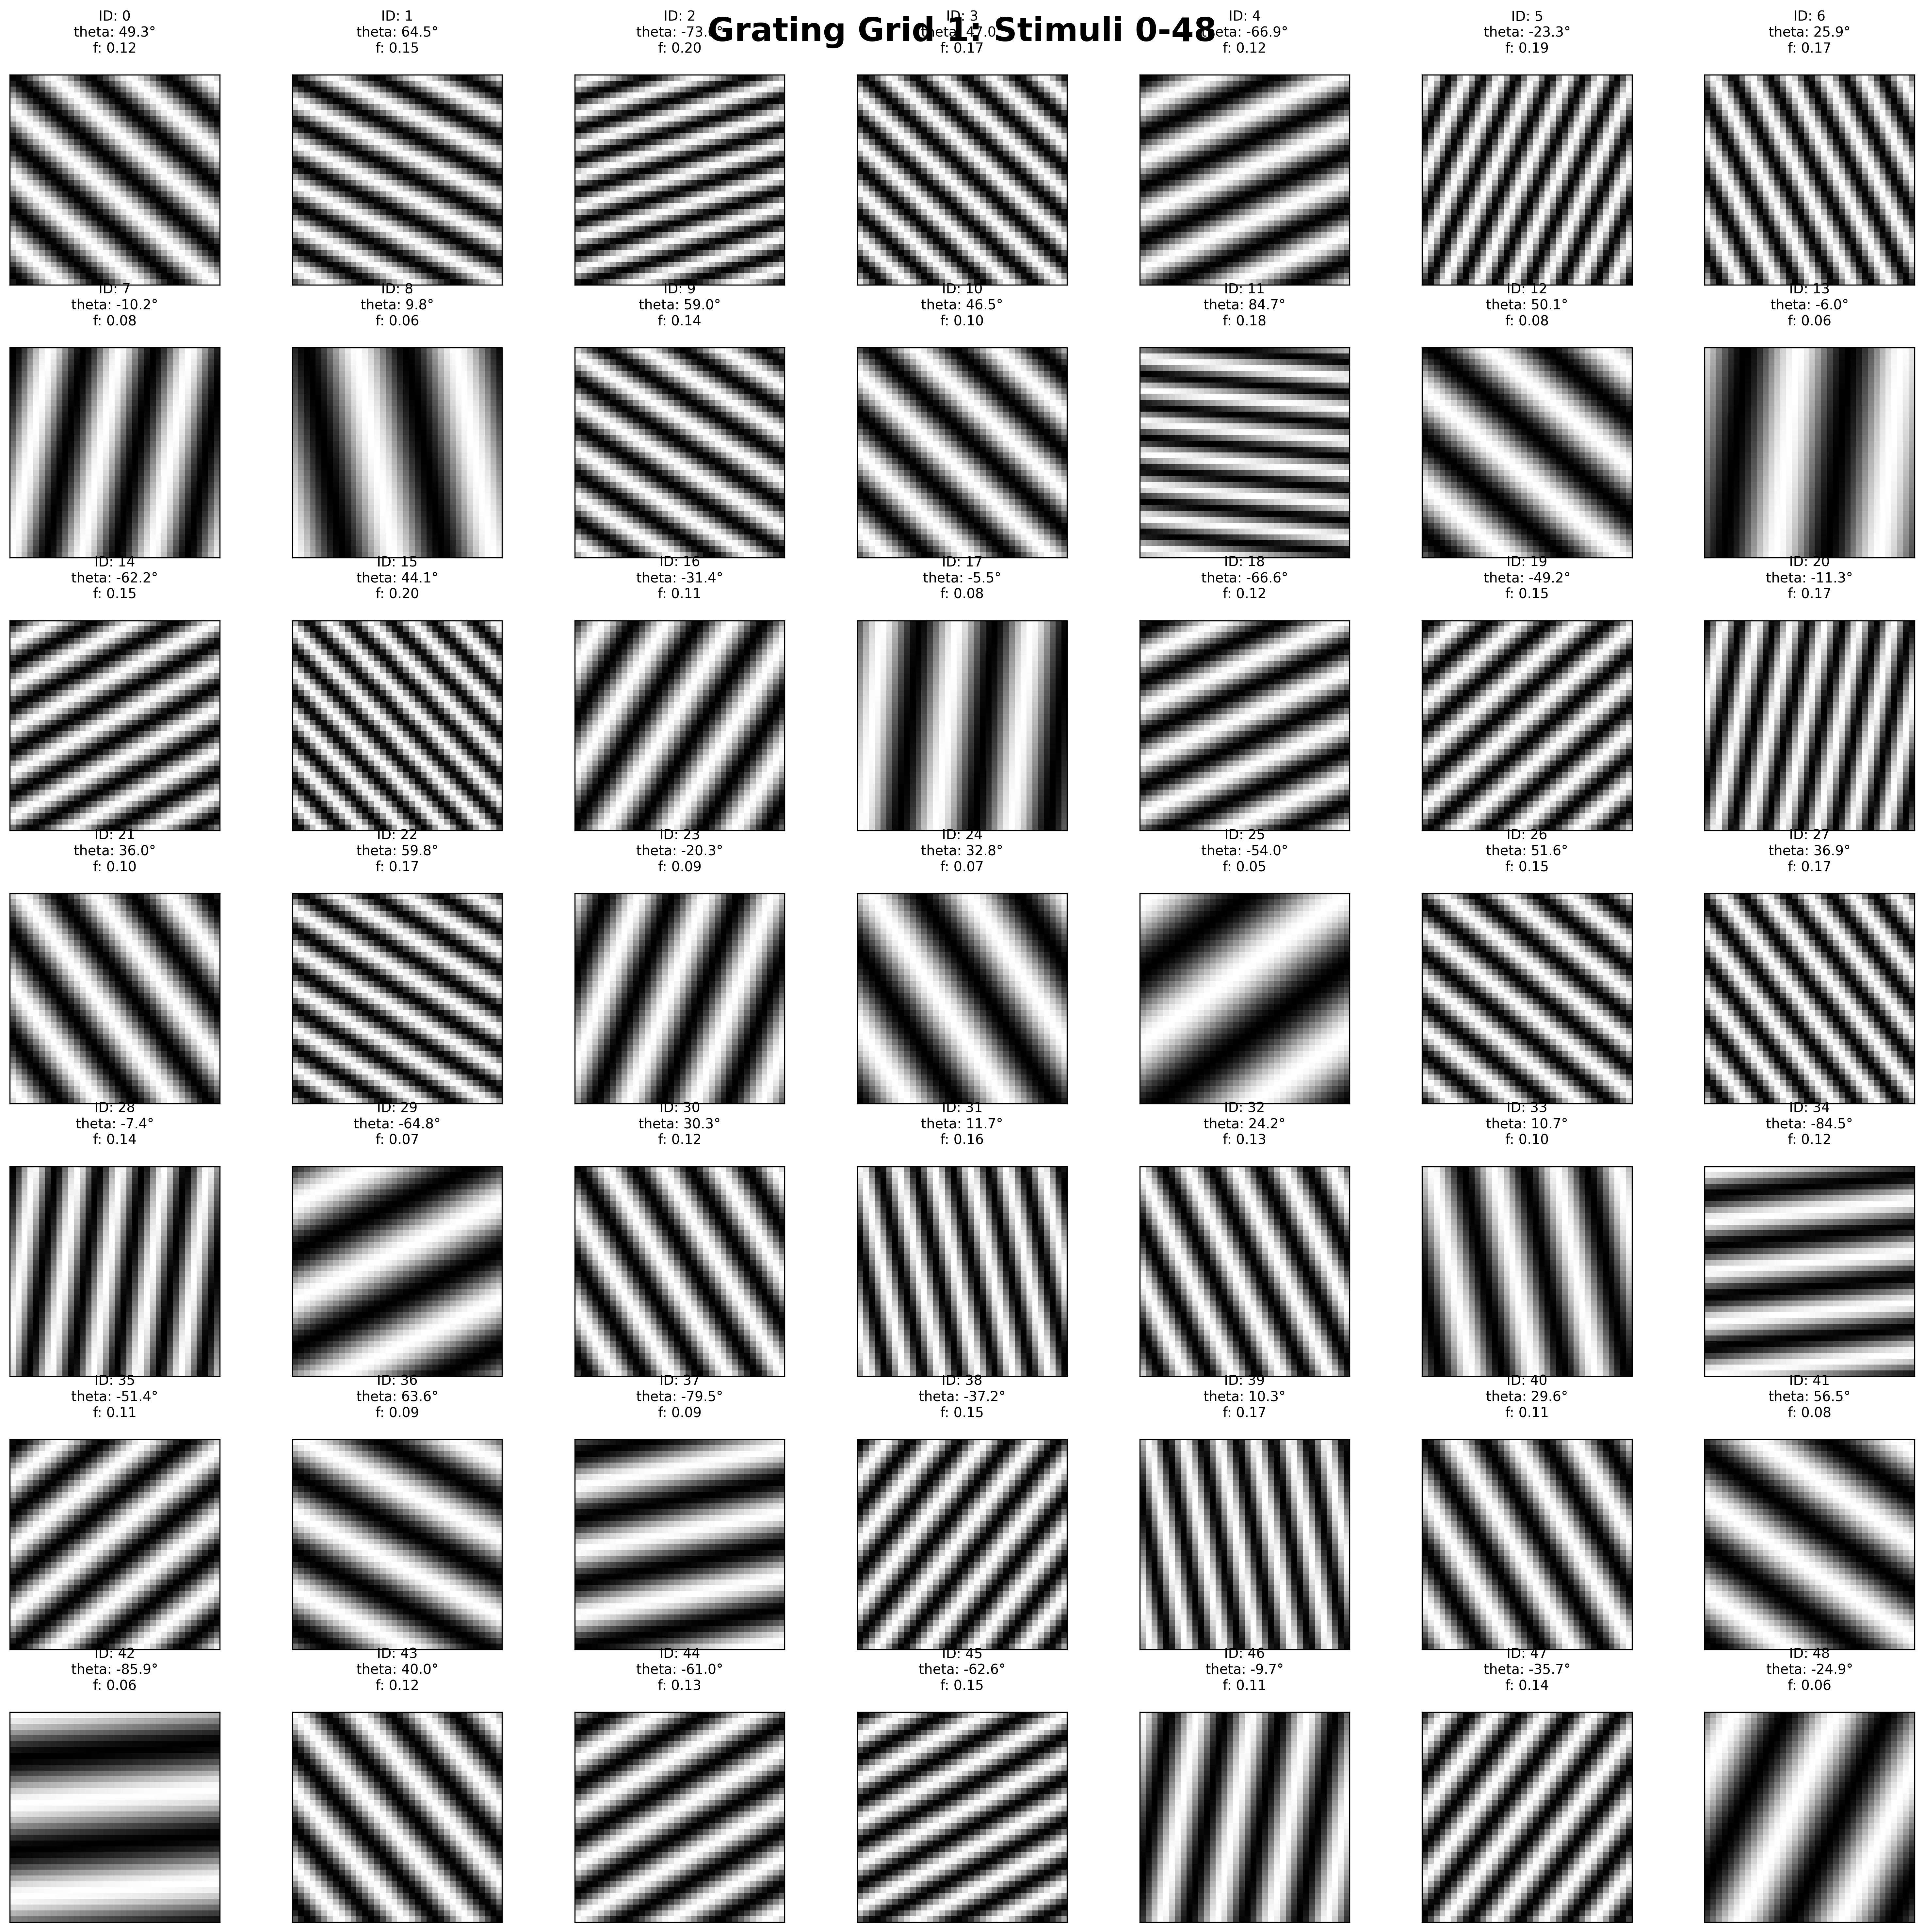

Grid 1 completed (gratings 0-48)


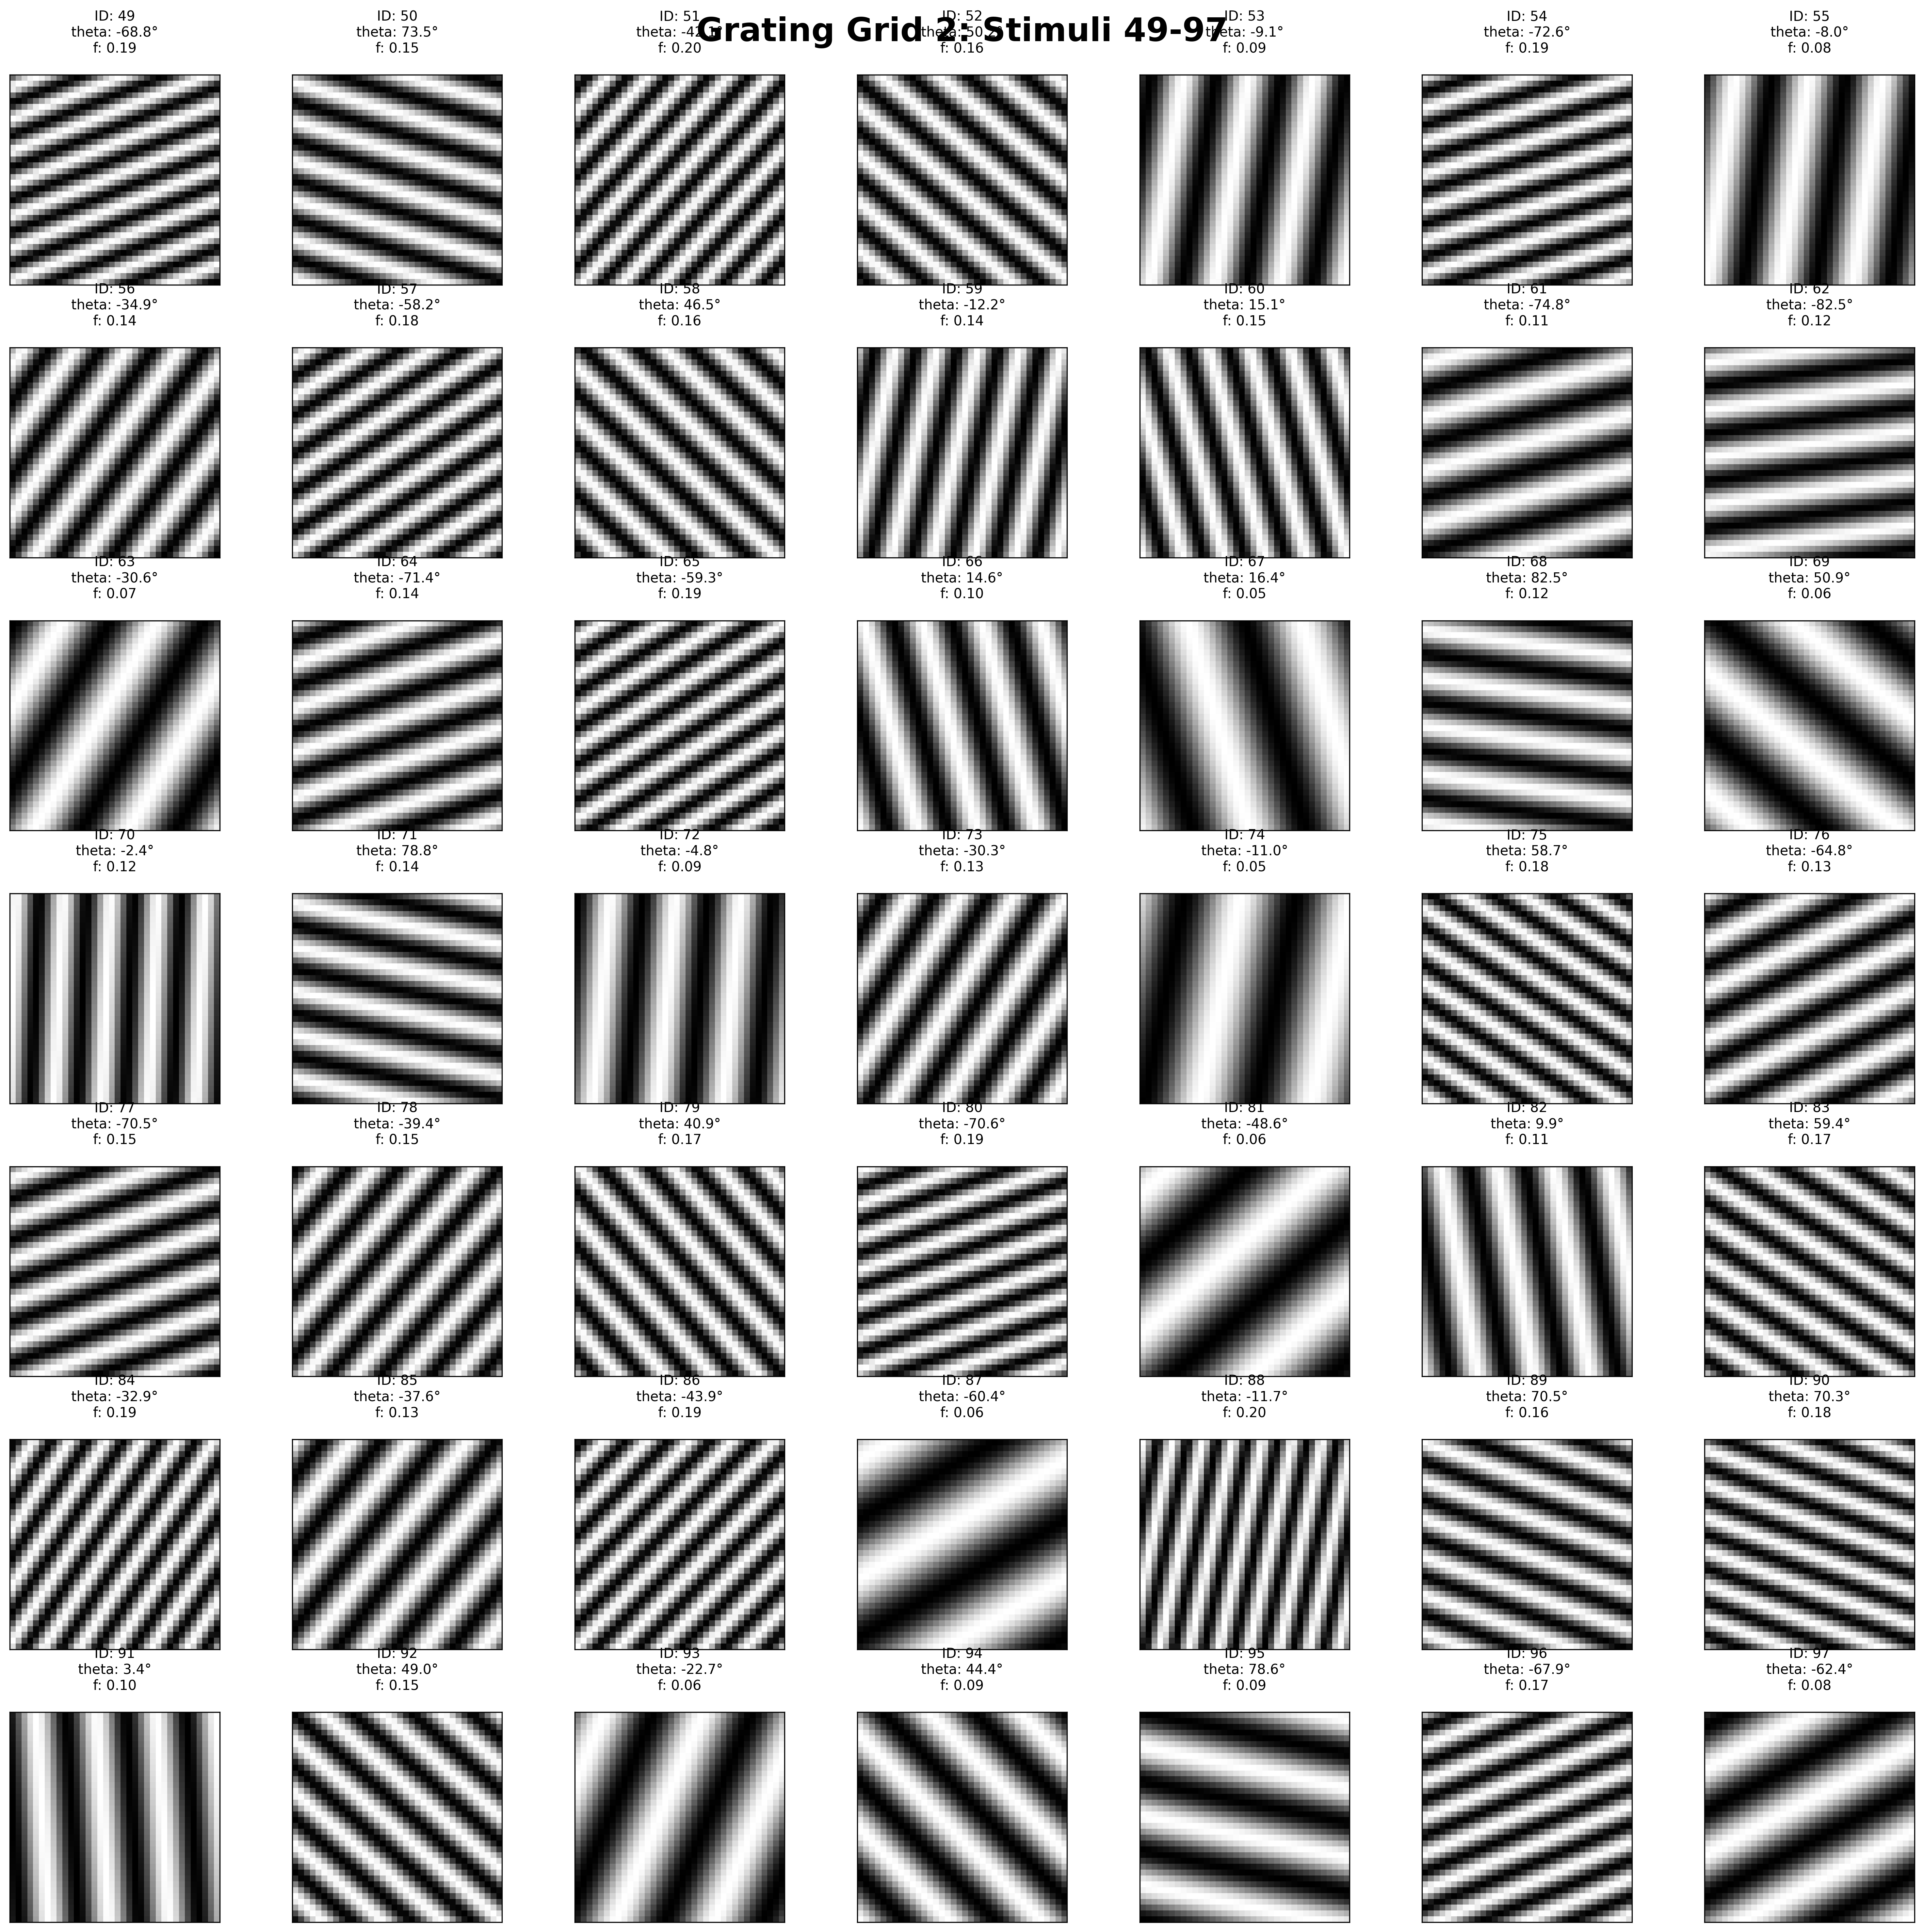

Grid 2 completed (gratings 49-97)


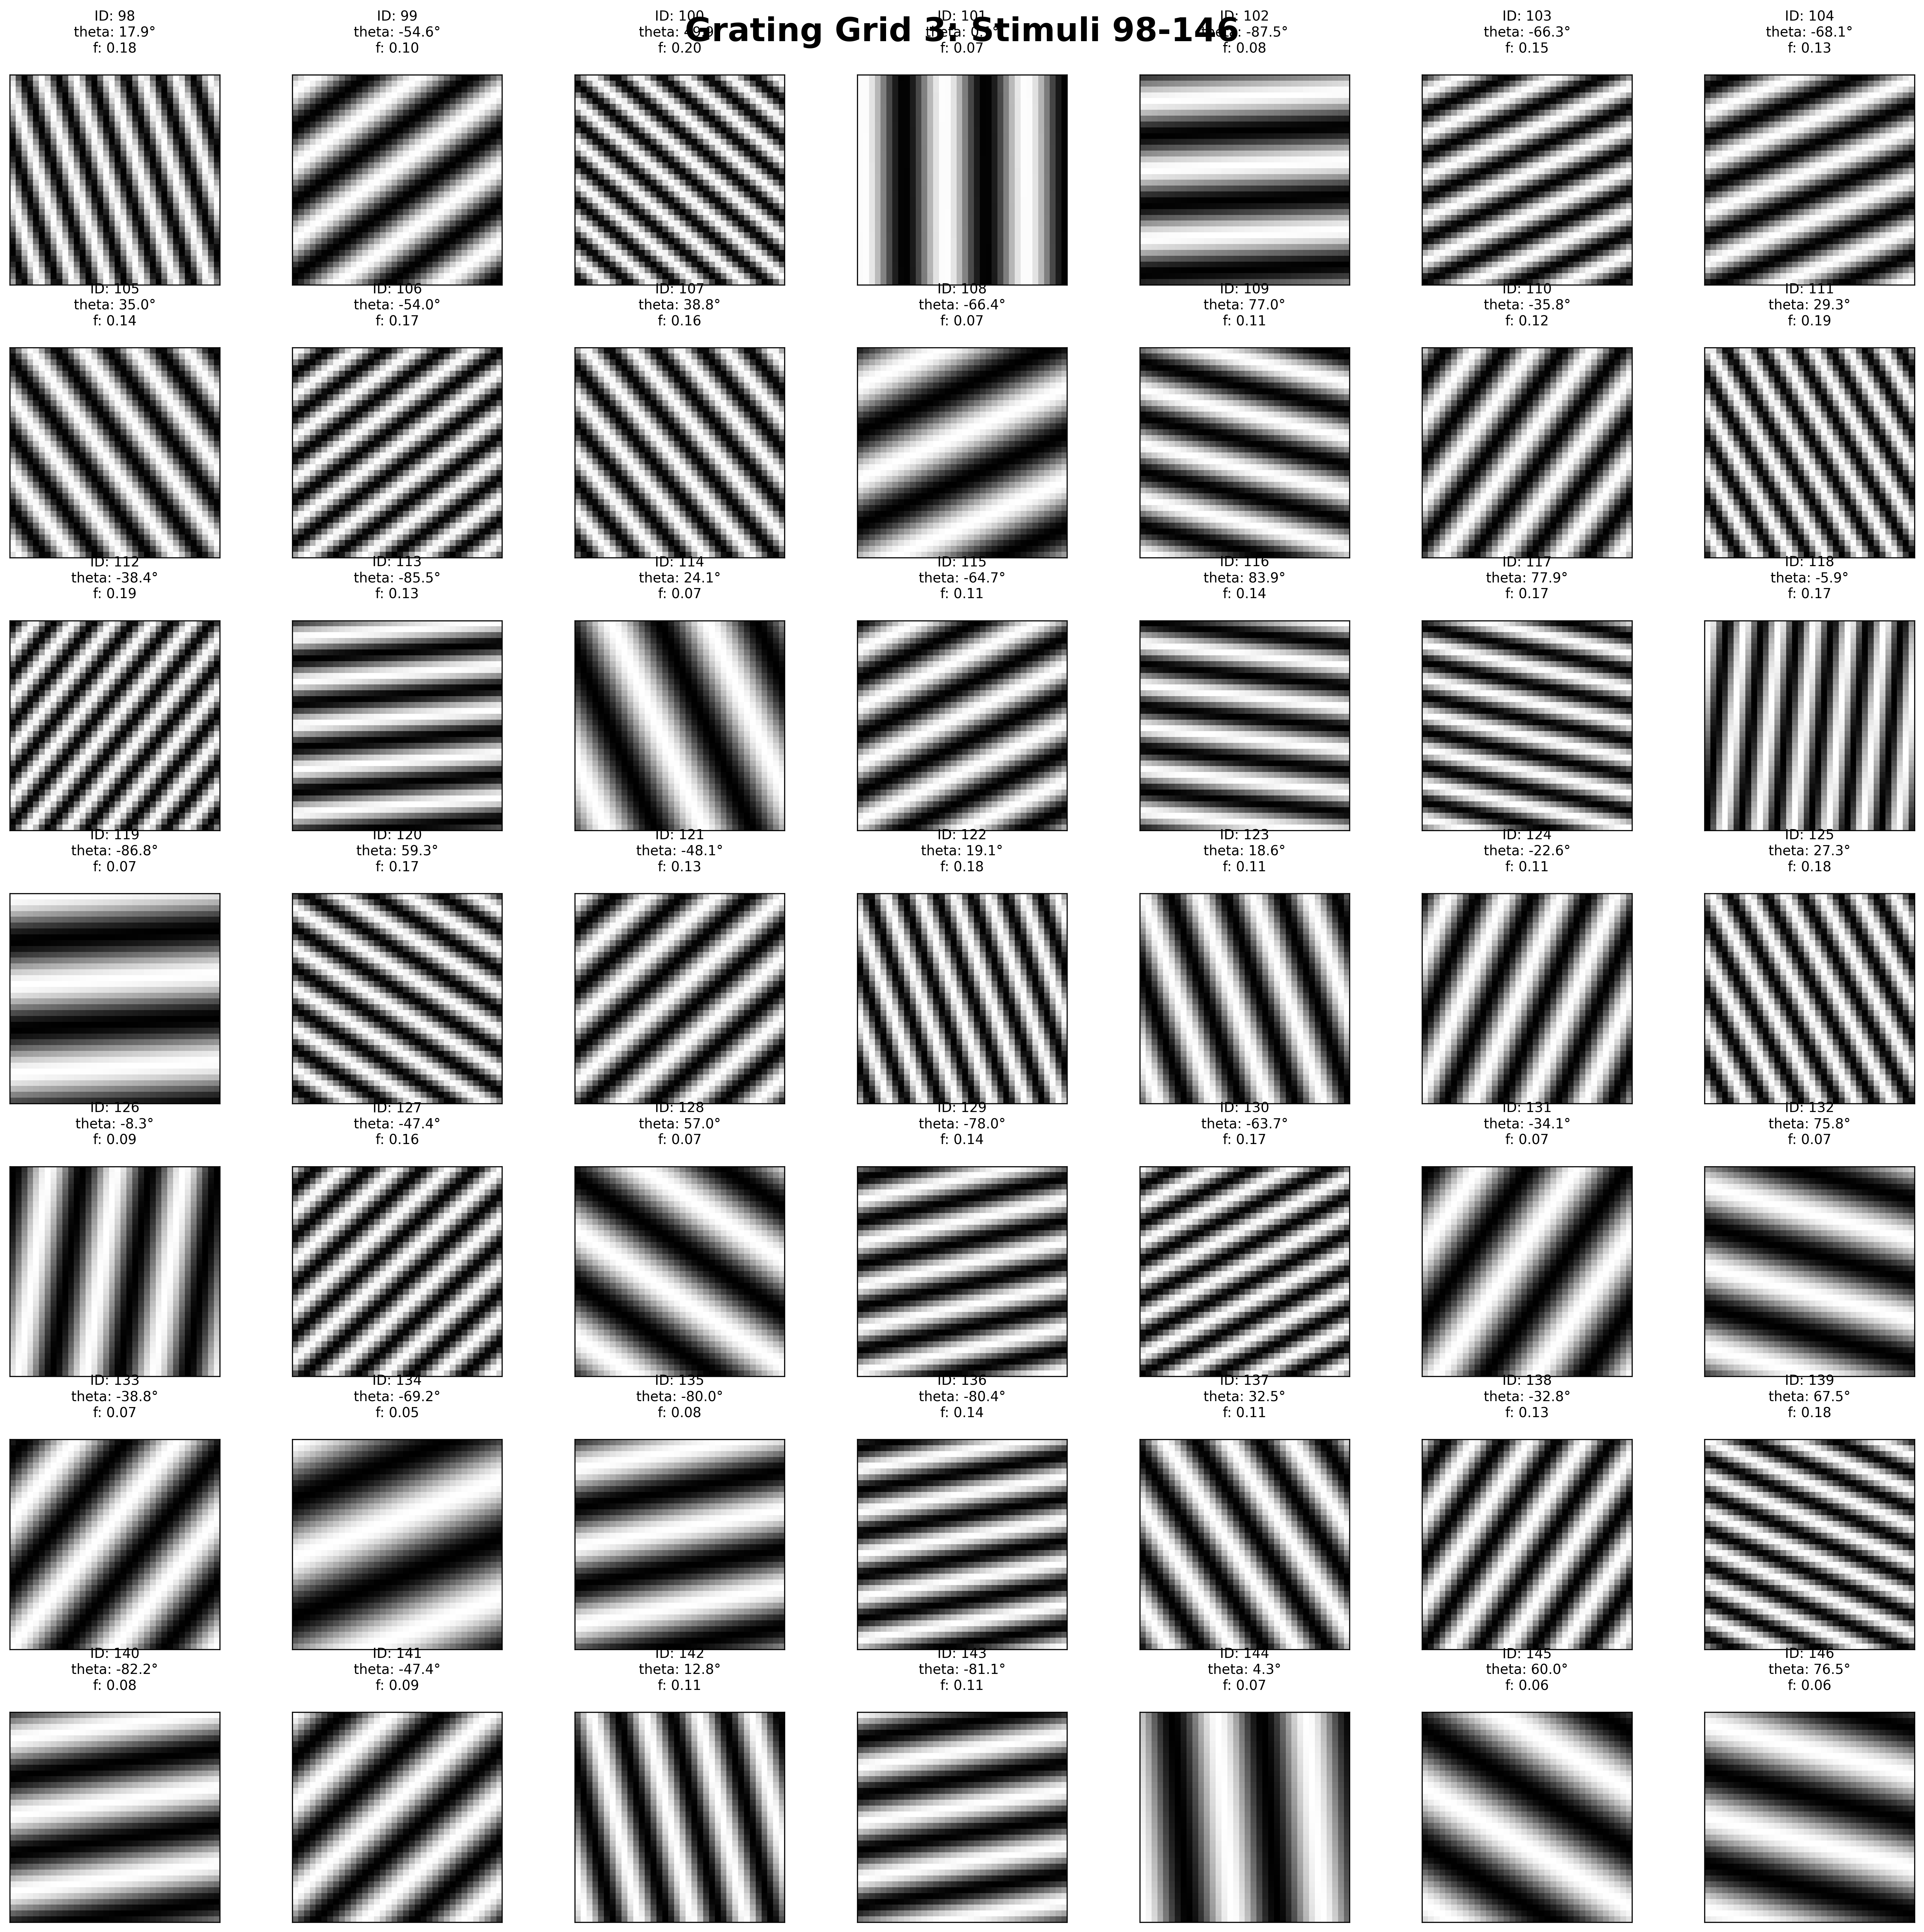

Grid 3 completed (gratings 98-146)

All 5 grids completed!
Each grid shows:
- ID: Grating index number
- θ: Orientation in degrees
- f: Spatial frequency (cycles/unit)

Total gratings displayed: 245 out of 1000


In [3]:
# Create 5 high-resolution 7x7 grids showing 49 gratings each
print("Creating 3 high-resolution 7x7 grids...")

for grid_num in range(3):
    start_idx = grid_num * 49
    end_idx = start_idx + 49
    
    # Create figure with high DPI
    fig, axes = plt.subplots(7, 7, figsize=(20, 20), dpi=300)
    fig.suptitle(f'Grating Grid {grid_num + 1}: Stimuli {start_idx}-{end_idx-1}', 
                 fontsize=24, fontweight='bold', y=0.98)
    
    for i in range(49):
        grating_idx = start_idx + i
        row = i // 7
        col = i % 7
        
        if grating_idx < len(gratings):
            # Display the grating
            axes[row, col].imshow(gratings[grating_idx], cmap="gray", vmin=-1, vmax=1)
            
            # Format parameter values for display
            params = grating_params[grating_idx]
            orientation_deg = np.degrees(params['orientation'])
            
            # Create title with parameters
            title = (f"ID: {grating_idx}\n"
                    f"theta: {orientation_deg:.1f}°\n"
                    f"f: {params['spatial_frequency']:.2f}\n")
            
            axes[row, col].set_title(title, fontsize=10, pad=5)
        else:
            # Hide empty subplots if we run out of gratings
            axes[row, col].set_visible(False)
        
        axes[row, col].set_xticks([])
        axes[row, col].set_yticks([])
    
    # Adjust layout to prevent overlap
    plt.tight_layout()
    plt.subplots_adjust(top=0.95, hspace=0.3, wspace=0.2)
    
    # Save the figure with high DPI
    plt.savefig(f'grating_grid_{grid_num + 1}.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"Grid {grid_num + 1} completed (gratings {start_idx}-{end_idx-1})")

print("\nAll 5 grids completed!")
print("Each grid shows:")
print("- ID: Grating index number")
print("- θ: Orientation in degrees")  
print("- f: Spatial frequency (cycles/unit)")
print("\nTotal gratings displayed: 245 out of 1000")

In [5]:
gratings.shape

(1000, 36, 36)

In [ ]:
# np.save("/src/project/experiments/exc_driven_model/coen_cagli_experiments/coen-cagli-gratings.npy", gratings)